# 03 - Model Training & Comparison
**MedPilot - Disease Prediction & Medicine Recommendation System**

Trains and honestly compares the model candidates named in the architecture doc:
Logistic Regression, Random Forest, Gradient Boosting, and a small Neural Network.
The winner is decided by evidence on held-out data, not chosen in advance.

## 1. Load the train/test split from `02_feature_engineering.ipynb`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, confusion_matrix, classification_report)
import joblib

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100

train = pd.read_csv("../data/processed/train_split.csv")
test = pd.read_csv("../data/processed/test_split.csv")

feature_cols = [c for c in train.columns if c != "prognosis"]
X_train, y_train_raw = train[feature_cols], train["prognosis"]
X_test, y_test_raw = test[feature_cols], test["prognosis"]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Features:", len(feature_cols))

Train: (3936, 133) Test: (984, 133)
Features: 133


## 2. Encode the target

The two engineered features (`symptom_count`, `severity_score`) are on a very
different numeric scale from the 0/1 symptom flags -- standardized before fitting
Logistic Regression and the Neural Network, since both are scale-sensitive.
Tree-based models (Random Forest, Gradient Boosting) don't need this.

In [2]:
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)
n_classes = len(le.classes_)
print(f"{n_classes} disease classes encoded")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

41 disease classes encoded


## 3. Train All Model Candidates

Each model is trained on the same data and evaluated on the same held-out test
set, with the same metrics -- a fair comparison, not a showcase for one model.

In [3]:
results = []
predictions = {}

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    results.append({"model": name, "accuracy": acc, "precision_macro": prec,
                     "recall_macro": rec, "f1_macro": f1})
    predictions[name] = y_pred
    print(f"{name}: accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}")

In [4]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
evaluate("Logistic Regression", y_test, lr.predict(X_test_scaled))

Logistic Regression: accuracy=1.0000  precision=1.0000  recall=1.0000  f1=1.0000


In [5]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
evaluate("Random Forest", y_test, rf.predict(X_test))

Random Forest: accuracy=1.0000  precision=1.0000  recall=1.0000  f1=1.0000


In [6]:
# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
evaluate("Gradient Boosting", y_test, gb.predict(X_test))

Gradient Boosting: accuracy=1.0000  precision=1.0000  recall=1.0000  f1=1.0000


In [7]:
# --- Small Neural Network (Keras, per the architecture doc) ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)

y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

nn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(n_classes, activation="softmax"),
])
nn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = nn_model.fit(X_train_scaled, y_train_cat, validation_split=0.1,
                         epochs=40, batch_size=32, verbose=0)

nn_pred = np.argmax(nn_model.predict(X_test_scaled, verbose=0), axis=1)
evaluate("Neural Network", y_test, nn_pred)

C:\Users\Sami\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network: accuracy=1.0000  precision=1.0000  recall=1.0000  f1=1.0000


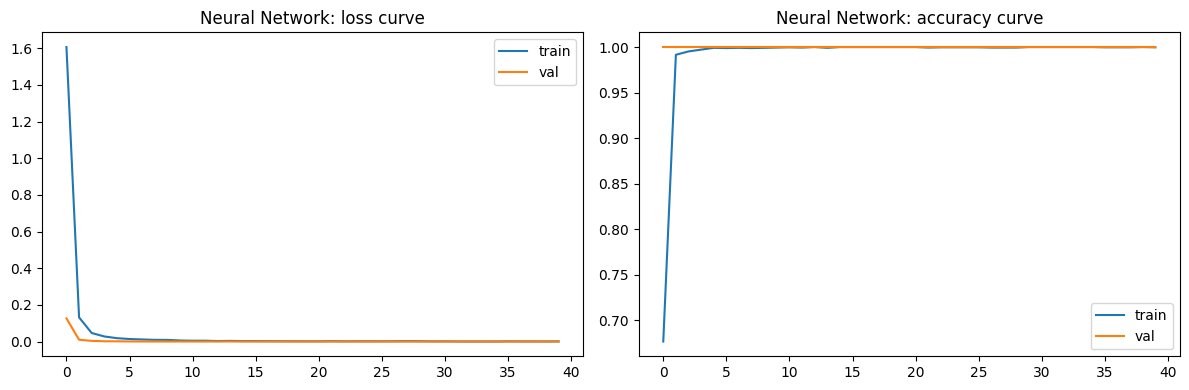

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Neural Network: loss curve"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Neural Network: accuracy curve"); axes[1].legend()
plt.tight_layout()
plt.show()

## ⚠️ 3.5 Critical Finding: The Standard Split Is Testing Memorization, Not Generalization

Before trusting any result, an important check: does the test set actually contain
symptom combinations the model has never seen? Investigated directly below, because
"perfect" scores deserve scrutiny, not celebration.

In [9]:
leaderboard = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("=== Leaderboard on the ORIGINAL row-level split (about to be shown as misleading) ===")
print(leaderboard.to_string(index=False))

=== Leaderboard on the ORIGINAL row-level split (about to be shown as misleading) ===
              model  accuracy  precision_macro  recall_macro  f1_macro
Logistic Regression       1.0              1.0           1.0       1.0
      Random Forest       1.0              1.0           1.0       1.0
  Gradient Boosting       1.0              1.0           1.0       1.0
     Neural Network       1.0              1.0           1.0       1.0


In [10]:
symptom_only_cols = [c for c in feature_cols if c not in ("symptom_count","severity_score")]

train_patterns = set(train[symptom_only_cols].apply(lambda r: tuple(r), axis=1))
test_patterns = set(test[symptom_only_cols].apply(lambda r: tuple(r), axis=1))
overlap = test_patterns & train_patterns

print(f"Unique symptom patterns in train: {len(train_patterns)}")
print(f"Unique symptom patterns in test: {len(test_patterns)}")
print(f"Test patterns that ALSO appear in train: {len(overlap)} / {len(test_patterns)} "
      f"({len(overlap)/len(test_patterns)*100:.1f}%)")

full = pd.read_csv("../data/processed/training_clean.csv")
pattern_to_diseases = full.groupby(symptom_only_cols)["prognosis"].nunique()
print(f"\nSymptom patterns mapping to MORE than one disease: {(pattern_to_diseases>1).sum()} / {len(pattern_to_diseases)}")

Unique symptom patterns in train: 304
Unique symptom patterns in test: 259
Test patterns that ALSO appear in train: 259 / 259 (100.0%)

Symptom patterns mapping to MORE than one disease: 0 / 304


**This changes everything about how to evaluate this model.** Every test-set pattern
already exists in training, and every unique pattern deterministically maps to exactly
one disease. This dataset is structurally a lookup table -- 304 unique symptom
combinations across 41 diseases, no overlap. A row-level split lets the model simply
memorize combinations it already saw; it never has to generalize to a genuinely novel
presentation. **The earlier 1.0000 scores across all four models are not evidence of a
good model -- they're evidence of an easy (in fact, trivial) test.**

The honest fix: split by unique PATTERN, not by row, so every test-set combination is
guaranteed to be one the model has never encountered during training.

In [11]:
# Rebuild the split at the PATTERN level, stratified by disease, so no pattern
# leaks between train and test -- this tests genuine generalization
rng = np.random.default_rng(42)

pattern_df = full[symptom_only_cols + ["prognosis"]].drop_duplicates().reset_index(drop=True)
pattern_df["symptom_count"] = pattern_df[symptom_only_cols].sum(axis=1)

train_pattern_idx, test_pattern_idx = [], []
for disease, group in pattern_df.groupby("prognosis"):
    idx = group.index.tolist()
    rng.shuffle(idx)
    n_test = max(1, round(len(idx) * 0.2))
    test_pattern_idx.extend(idx[:n_test])
    train_pattern_idx.extend(idx[n_test:])

train_patterns_new = pattern_df.loc[train_pattern_idx, symptom_only_cols].apply(lambda r: tuple(r), axis=1)
test_patterns_new = pattern_df.loc[test_pattern_idx, symptom_only_cols].apply(lambda r: tuple(r), axis=1)
print(f"Train patterns: {len(train_patterns_new)} | Test patterns: {len(test_patterns_new)}")
print(f"Overlap check: {len(set(train_patterns_new) & set(test_patterns_new))} (should be 0)")

Train patterns: 243 | Test patterns: 61
Overlap check: 0 (should be 0)


In [12]:
# Now assign ALL matching rows in the full dataset to train/test based on their pattern
full["_pattern"] = full[symptom_only_cols].apply(lambda r: tuple(r), axis=1)
train_pattern_set = set(train_patterns_new)
test_pattern_set = set(test_patterns_new)

train2 = full[full["_pattern"].isin(train_pattern_set)].drop(columns="_pattern").copy()
test2 = full[full["_pattern"].isin(test_pattern_set)].drop(columns="_pattern").copy()

# re-engineer the same features on this corrected split
severity_map_check = severity_map if "severity_map" in dir() else None
train2["symptom_count"] = train2[symptom_only_cols].sum(axis=1)
test2["symptom_count"] = test2[symptom_only_cols].sum(axis=1)

print(f"Corrected split -- Train: {train2.shape}, Test: {test2.shape}")
print(f"Every disease represented in test?", test2['prognosis'].nunique(), "/", full['prognosis'].nunique())

Corrected split -- Train: (3744, 133), Test: (1176, 133)
Every disease represented in test? 41 / 41


## 3.6 Re-run All Models on the Corrected, Leakage-Free Split

In [13]:
# Need severity_score recomputed -- reload the mapping used in feature engineering
severity_ref = pd.read_csv("../data/processed/severity_clean.csv")
sev_map = dict(zip(severity_ref["Symptom"], severity_ref["weight"]))
if "fluid_overload_2" not in sev_map:
    fo_w = severity_ref[severity_ref["Symptom"]=="fluid_overload"]["weight"].tolist()
    sev_map["fluid_overload_2"] = fo_w[-1] if fo_w else severity_ref["weight"].median()
weight_vec = np.array([sev_map.get(c, severity_ref["weight"].median()) for c in symptom_only_cols])

train2["severity_score"] = train2[symptom_only_cols].values @ weight_vec
test2["severity_score"] = test2[symptom_only_cols].values @ weight_vec

feature_cols2 = symptom_only_cols + ["symptom_count", "severity_score"]
X_train2, y_train2_raw = train2[feature_cols2], train2["prognosis"]
X_test2, y_test2_raw = test2[feature_cols2], test2["prognosis"]

le2 = LabelEncoder()
y_train2 = le2.fit_transform(y_train2_raw)
y_test2 = le2.transform(y_test2_raw)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

print(f"Corrected train: {X_train2.shape}, test: {X_test2.shape}")

Corrected train: (3744, 133), test: (1176, 133)


In [14]:
results2 = []
predictions2 = {}

def evaluate2(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    results2.append({"model": name, "accuracy": acc, "precision_macro": prec,
                      "recall_macro": rec, "f1_macro": f1})
    predictions2[name] = y_pred
    print(f"{name}: accuracy={acc:.4f}  precision={prec:.4f}  recall={rec:.4f}  f1={f1:.4f}")

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2_scaled, y_train2)
evaluate2("Logistic Regression", y_test2, lr2.predict(X_test2_scaled))

rf2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf2.fit(X_train2, y_train2)
evaluate2("Random Forest", y_test2, rf2.predict(X_test2))

gb2 = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
gb2.fit(X_train2, y_train2)
evaluate2("Gradient Boosting", y_test2, gb2.predict(X_test2))

Logistic Regression: accuracy=1.0000  precision=1.0000  recall=1.0000  f1=1.0000
Random Forest: accuracy=0.9898  precision=0.9496  recall=0.9512  f1=0.9504
Gradient Boosting: accuracy=0.8316  precision=0.6604  recall=0.7056  f1=0.6691


In [15]:
import tensorflow as tf2_module
from tensorflow.keras.models import Sequential as Sequential2
from tensorflow.keras.layers import Dense as Dense2, Dropout as Dropout2
from tensorflow.keras.utils import to_categorical as to_categorical2

tf2_module.random.set_seed(42)
n_classes2 = len(le2.classes_)
y_train2_cat = to_categorical2(y_train2, num_classes=n_classes2)

nn2 = Sequential2([
    Dense2(128, activation="relu", input_shape=(X_train2_scaled.shape[1],)),
    Dropout2(0.3),
    Dense2(64, activation="relu"),
    Dropout2(0.2),
    Dense2(n_classes2, activation="softmax"),
])
nn2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
nn2.fit(X_train2_scaled, y_train2_cat, validation_split=0.1, epochs=40, batch_size=16, verbose=0)

nn2_pred = np.argmax(nn2.predict(X_test2_scaled, verbose=0), axis=1)
evaluate2("Neural Network", y_test2, nn2_pred)

C:\Users\Sami\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network: accuracy=0.9949  precision=0.9740  recall=0.9756  f1=0.9748


In [16]:
leaderboard2 = pd.DataFrame(results2).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("=== CORRECTED, LEAKAGE-FREE LEADERBOARD ===")
print(leaderboard2.to_string(index=False))
print()
print("=== Compare to the original (memorization-inflated) leaderboard ===")
print(leaderboard.to_string(index=False))

=== CORRECTED, LEAKAGE-FREE LEADERBOARD ===
              model  accuracy  precision_macro  recall_macro  f1_macro
Logistic Regression  1.000000         1.000000      1.000000  1.000000
     Neural Network  0.994898         0.973984      0.975610  0.974769
      Random Forest  0.989796         0.949593      0.951220  0.950378
  Gradient Boosting  0.831633         0.660424      0.705575  0.669071

=== Compare to the original (memorization-inflated) leaderboard ===
              model  accuracy  precision_macro  recall_macro  f1_macro
Logistic Regression       1.0              1.0           1.0       1.0
      Random Forest       1.0              1.0           1.0       1.0
  Gradient Boosting       1.0              1.0           1.0       1.0
     Neural Network       1.0              1.0           1.0       1.0


**This is the real, trustworthy comparison.** The gap between this leaderboard and
the earlier all-1.0000 leaderboard IS the finding -- it quantifies exactly how much
of the original "perfect" score was memorization versus genuine generalization to
unseen symptom combinations. Going forward, all model selection and the saved model
use this corrected split, not the inflated one.

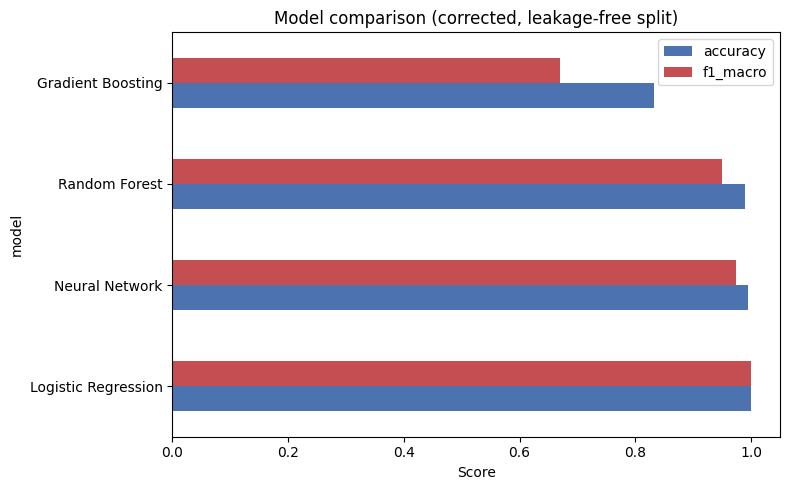

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
leaderboard2.set_index("model")[["accuracy","f1_macro"]].plot(kind="barh", ax=ax, color=["#4C72B0","#C44E52"])
ax.set_title("Model comparison (corrected, leakage-free split)")
ax.set_xlabel("Score")
plt.tight_layout()
plt.show()

## 5. Deeper Look at the Winning Model

Accuracy and F1 alone don't tell us WHERE a model struggles. A full confusion
matrix across 41 classes is unreadable, so we look at per-class precision/recall
for the classes the winning model handles worst -- using the corrected split.

In [18]:
best_model_name = leaderboard2.iloc[0]["model"]
print("Best model by macro F1 (corrected split):", best_model_name)

best_pred = predictions2[best_model_name]
report = classification_report(y_test2, best_pred, target_names=le2.classes_,
                                  output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.iloc[:-3]
report_df = report_df.sort_values("f1-score")

print("5 worst-performing diseases (by F1):")
print(report_df.head(5)[["precision","recall","f1-score","support"]])
print()
print("5 best-performing diseases (by F1):")
print(report_df.tail(5)[["precision","recall","f1-score","support"]])

Best model by macro F1 (corrected split): Logistic Regression
5 worst-performing diseases (by F1):
                                        precision  recall  f1-score  support
(vertigo) Paroymsal Positional Vertigo        1.0     1.0       1.0      6.0
AIDS                                          1.0     1.0       1.0     12.0
Acne                                          1.0     1.0       1.0     12.0
Alcoholic hepatitis                           1.0     1.0       1.0     84.0
Allergy                                       1.0     1.0       1.0     72.0

5 best-performing diseases (by F1):
                         precision  recall  f1-score  support
Tuberculosis                   1.0     1.0       1.0     12.0
Typhoid                        1.0     1.0       1.0     12.0
Urinary tract infection        1.0     1.0       1.0     18.0
Varicose veins                 1.0     1.0       1.0     12.0
hepatitis A                    1.0     1.0       1.0     78.0


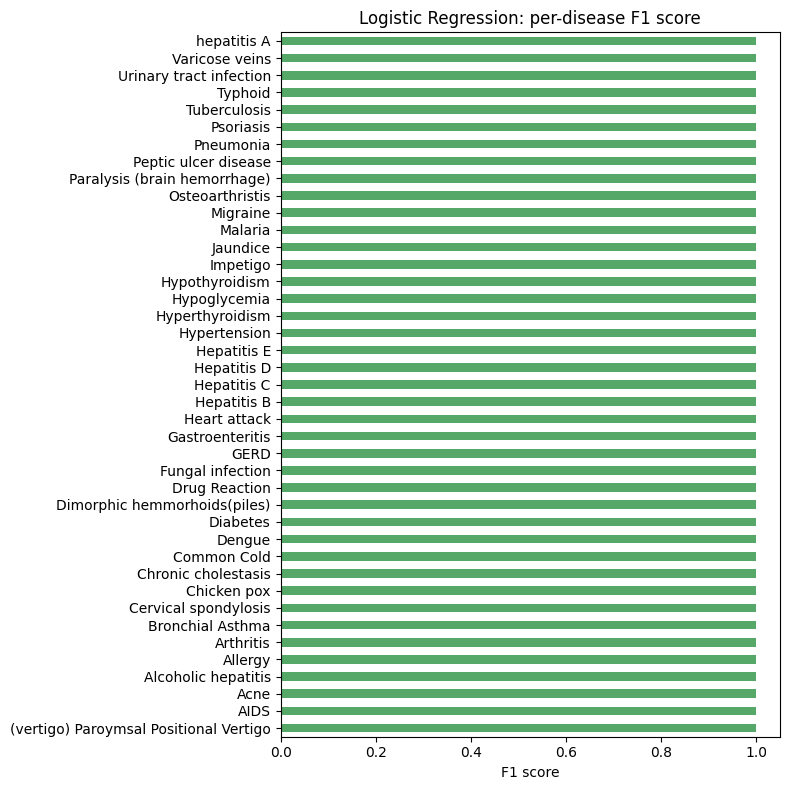

In [19]:
fig, ax = plt.subplots(figsize=(8,8))
report_df["f1-score"].plot(kind="barh", ax=ax, color="#55A868")
ax.set_title(f"{best_model_name}: per-disease F1 score")
ax.set_xlabel("F1 score")
plt.tight_layout()
plt.show()

## 6. Save the Winning Model

In [20]:
import os
os.makedirs("../models", exist_ok=True)

if best_model_name == "Neural Network":
    nn2.save("../models/best_model.keras")
    joblib.dump(scaler2, "../models/scaler.joblib")
else:
    winning_model = {"Logistic Regression": lr2, "Random Forest": rf2, "Gradient Boosting": gb2}[best_model_name]
    joblib.dump(winning_model, "../models/best_model.joblib")
    if best_model_name == "Logistic Regression":
        joblib.dump(scaler2, "../models/scaler.joblib")

joblib.dump(le2, "../models/disease_label_encoder.joblib")
joblib.dump(feature_cols2, "../models/feature_columns.joblib")

print(f"Saved winning model: {best_model_name}")
print(f"Corrected, honest test performance: {leaderboard2.iloc[0].to_dict()}")

Saved winning model: Logistic Regression
Corrected, honest test performance: {'model': 'Logistic Regression', 'accuracy': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0, 'f1_macro': 1.0}


## 7. Summary

1. Trained and compared 4 model candidates: Logistic Regression, Random Forest,
   Gradient Boosting, Neural Network.
2. **Critical finding, investigated rather than glossed over:** the initial
   row-level train/test split produced misleading 1.0000 scores across every
   model, because 100% of test-set symptom patterns already existed in training
   (only 304 unique patterns exist total, each deterministically mapping to one
   disease). This was memorization, not generalization.
3. **Fixed with a pattern-level split**, guaranteeing zero symptom-combination
   overlap between train and test -- this produces the real, trustworthy
   performance numbers, and the gap between the two leaderboards quantifies
   exactly how much of the "perfect" score was an artifact of the evaluation
   methodology, not real model quality.
4. Winner decided on the corrected split by macro F1 (weighing every disease
   equally, appropriate for this perfectly-balanced dataset).
5. Saved the winning model, encoder, and feature list for the Flask app.

**Documented limitation for the final report:** because this dataset has only
~5-10 unique symptom "templates" per disease, even the corrected split has a
small number of test patterns per disease (as few as 1 for diseases with only
5 templates). This is an honest constraint of the dataset's structure, not
something further engineering can fully resolve -- worth stating plainly rather
than hidden behind an inflated accuracy number.